# Output files

In [1]:
import pandas  as pd 
import json 


output_files_dict = {
    "WVS_US_llama_vanilla": "/data/gpfs/projects/punim2219/LM_with_SWOW/chunhua/Data/output/llama/WVS_US_llama_vanilla.json",
    "WVS_US_llama_sft": "/data/gpfs/projects/punim2219/LM_with_SWOW/chunhua/Data/output/llama/WVS_US_llama_sft.json",
    "WVS_US_llama_ppo": "/data/gpfs/projects/punim2219/LM_with_SWOW/chunhua/Data/output/llama/WVS_US_llama_ppo.json",
    "WVS_US_llama_ftd_n_ppo": "/data/gpfs/projects/punim2219/LM_with_SWOW/chunhua/Data/output/llama/WVS_US_llama_ftd_n_ppo.json",

    "WVS_US_qwen_vanilla": "/data/gpfs/projects/punim2219/LM_with_SWOW/chunhua/Data/output/qwen/WVS_US_qwen_vanilla.json",
    "WVS_US_qwen_sft": "/data/gpfs/projects/punim2219/LM_with_SWOW/chunhua/Data/output/qwen/WVS_US_qwen_sft.json",
    "WVS_US_qwen_ppo": "/data/gpfs/projects/punim2219/LM_with_SWOW/chunhua/Data/output/qwen/WVS_US_qwen_ppo.json",
    "WVS_US_qwen_ftd_n_ppo": "/data/gpfs/projects/punim2219/LM_with_SWOW/chunhua/Data/output/qwen/WVS_US_qwen_ftd_n_ppo.json",

    "WVS_ZH_llama_vanilla": "/data/gpfs/projects/punim2219/LM_with_SWOW/chunhua/Data/output/llama/WVS_ZH_llama_vanilla.json",
    "WVS_ZH_llama_sft": "/data/gpfs/projects/punim2219/LM_with_SWOW/chunhua/Data/output/llama/WVS_ZH_llama_sft.json",
    "WVS_ZH_llama_ppo": "/data/gpfs/projects/punim2219/LM_with_SWOW/chunhua/Data/output/llama/WVS_ZH_llama_ppo.json",
    "WVS_ZH_llama_ftd_n_ppo": "/data/gpfs/projects/punim2219/LM_with_SWOW/chunhua/Data/output/llama/WVS_ZH_llama_ftd_n_ppo.json",

    "WVS_ZH_qwen_vanilla": "/data/gpfs/projects/punim2219/LM_with_SWOW/chunhua/Data/output/qwen/WVS_ZH_qwen_vanilla.json",
    "WVS_ZH_qwen_sft": "/data/gpfs/projects/punim2219/LM_with_SWOW/chunhua/Data/output/qwen/WVS_ZH_qwen_sft.json",
    "WVS_ZH_qwen_ppo": "/data/gpfs/projects/punim2219/LM_with_SWOW/chunhua/Data/output/qwen/WVS_ZH_qwen_ppo.json",
    "WVS_ZH_qwen_ftd_n_ppo": "/data/gpfs/projects/punim2219/LM_with_SWOW/chunhua/Data/output/qwen/WVS_ZH_qwen_ftd_n_ppo.json"
}


# Overall score

In [2]:


def get_average_earth_mover_score(path): 
    results = json.load(open(path, 'r'))

    missing_indices = [i for i, item in enumerate(results) if 'earth_mover_distance' not in item]
    mean_em_score = sum(item['earth_mover_distance'] for i, item in enumerate(results) if i not in missing_indices) / (len(results) - len(missing_indices)) if len(results) > len(missing_indices) else float('nan')
    return mean_em_score


results_df = []
for model, path in output_files_dict.items():
    mean_em_score = get_average_earth_mover_score(path)
    print(f"{model}: {mean_em_score}")
    country_name = model.split("_")[1]
    model_class = model.split("_")[2]

    model_type = "_".join(model.split("_")[2:])

    results_df.append({"country_name": country_name,
                     "model_class": model_class, 
                    "model_type": model_type, 
                     "earth_mover_score": mean_em_score})

results_df = pd.DataFrame(data=results_df)

display(results_df)

WVS_US_llama_vanilla: 0.1021926346512363
WVS_US_llama_sft: 0.09319601698991424
WVS_US_llama_ppo: 0.10066267317452568
WVS_US_llama_ftd_n_ppo: 0.09413170950260943
WVS_US_qwen_vanilla: 0.13147752673560598
WVS_US_qwen_sft: 0.12249260940448783
WVS_US_qwen_ppo: 0.13138308007096663
WVS_US_qwen_ftd_n_ppo: 0.12062508219116289
WVS_ZH_llama_vanilla: 0.15217790169856701
WVS_ZH_llama_sft: 0.1292013280554378
WVS_ZH_llama_ppo: 0.14759534480378203
WVS_ZH_llama_ftd_n_ppo: 0.12689186250860393
WVS_ZH_qwen_vanilla: 0.13890384209736265
WVS_ZH_qwen_sft: 0.10026087200872835
WVS_ZH_qwen_ppo: 0.13863934098090644
WVS_ZH_qwen_ftd_n_ppo: 0.1030931701706217


,country_name,model_class,model_type,earth_mover_score
0,US,llama,llama_vanilla,0.102193
1,US,llama,llama_sft,0.093196
2,US,llama,llama_ppo,0.100663
3,US,llama,llama_ftd_n_ppo,0.094132
4,US,qwen,qwen_vanilla,0.131478
5,US,qwen,qwen_sft,0.122493
6,US,qwen,qwen_ppo,0.131383
7,US,qwen,qwen_ftd_n_ppo,0.120625
8,ZH,llama,llama_vanilla,0.152178
9,ZH,llama,llama_sft,0.129201


## EM divided by Option num

In [3]:
import pandas  as pd 
import json 


def get_average_earth_mover_score_by_level(path):
    # Load data
    results = json.load(open(path, 'r'))
    
    # Filter rows with earth_mover_distance
    results = [ item for _, item in enumerate(results) if 'earth_mover_distance' in item]
    
    # Convert to DataFrame
    df = pd.DataFrame(results)
    
  
    # Add option_num column
    df['option_num'] = df['survey_scores'].astype(str).apply(lambda x: len(eval(x).keys()) if x != 'nan' else None)
    
    # Drop rows where option_num couldn't be extracted
    df = df.dropna(subset=['option_num'])
    
    # Create level column
    df['level'] = df['option_num'].apply(lambda x: str(int(x)) if x < 5 else '>=5')
    
    # Calculate means by level
    level_means = df.groupby('level')['earth_mover_distance'].mean().to_dict()
    level_counts = df.groupby('level').size().to_dict()
    
    # print(level_means)
    # print(level_counts)
    # Add overall stats
    level_means['overall'] = df['earth_mover_distance'].mean()
    level_counts['overall'] = len(df)
    return {'level_means': level_means, 'level_counts': level_counts}


results_df = []
for model, path in output_files_dict.items():
    # Get results by level
    level_results = get_average_earth_mover_score_by_level(path)
    
    # print(f"{model} results:")
    # print(f"  Means by level: {level_results['level_means']}")
    # print(f"  Counts by level: {level_results['level_counts']}")
    
    country_name = model.split("_")[1]
    model_class = model.split("_")[2]
    model_type = "_".join(model.split("_")[2:])
    
    # Add overall score to main results
    results_df.append({
        "country_name": country_name,
        "model_class": model_class, 
        "model_type": model_type, 
        # f"em(2 | {level_results['level_counts']['2']})": level_results['level_means']['2'],
        # f"em(3 | {level_results['level_counts']['3']})": level_results['level_means']['3'],
        # f"em(4 | {level_results['level_counts']['4']})": level_results['level_means']['4'],
        # f"em(>=5 | {level_results['level_counts']['>=5']})": level_results['level_means']['>=5'],
        f"em(2)": level_results['level_means']['2'],
        f"em(3)": level_results['level_means']['3'],
        f"em(4)": level_results['level_means']['4'],
        f"em(>=5": level_results['level_means']['>=5'],
        f"em_overall": level_results['level_means']['overall']
    })

# Convert to DataFrame
results_df = pd.DataFrame(data=results_df)
display(results_df)

,country_name,model_class,model_type,em(2),em(3),em(4),em(>=5,em_overall
0,US,llama,llama_vanilla,0.208040,0.140920,0.085068,0.046461,0.102193
1,US,llama,llama_sft,0.175469,0.115095,0.082189,0.052723,0.093196
2,US,llama,llama_ppo,0.213790,0.136487,0.080401,0.046858,0.100663
3,US,llama,llama_ftd_n_ppo,0.174753,0.125389,0.079008,0.052795,0.094132
4,US,qwen,qwen_vanilla,0.185677,0.153122,0.150693,0.071339,0.131478
5,US,qwen,qwen_sft,0.102700,0.169922,0.134910,0.087243,0.122493
6,US,qwen,qwen_ppo,0.188894,0.150628,0.150723,0.071139,0.131383
7,US,qwen,qwen_ftd_n_ppo,0.095229,0.169158,0.133044,0.087253,0.120625
8,ZH,llama,llama_vanilla,0.158491,0.230046,0.163357,0.093231,0.152178
9,ZH,llama,llama_sft,0.100435,0.224324,0.145254,0.070875,0.129201


# Add Other metrics

In [1]:
from evaluate import evaluate_model_distributions

path = "/data/gpfs/projects/punim2219/LM_with_SWOW/chunhua/Data/output/llama/WVS_US_llama_vanilla.json"
results_tmp = evaluate_model_distributions(path)
results_tmp


{'metrics': {'earth_movers_distance': {'2': 0.5004495582359896,
   '3': 0.6034129499606986,
   '4': 0.6412125472964286,
   '>=5': 1.2274477583790435,
   'overall': 0.7961665384034807},
  'jensen_shannon': {'2': 0.40548149257849764,
   '3': 0.3536068034186247,
   '4': 0.2967011598410805,
   '>=5': 0.2965892842103377,
   'overall': 0.32400435074635464},
  'earth_movers_distance_normalized': {'2': 0.5004495582359896,
   '3': 0.3017064749803493,
   '4': 0.21373751576547623,
   '>=5': 0.16069827725835392,
   'overall': 0.25660485090907026},
  'kl_divergence_gt_to_pred': {'2': 1.0880887446127052,
   '3': 1.2317501378740339,
   '4': 0.4455058173170938,
   '>=5': 0.4678473577072597,
   'overall': 0.7056199095589186},
  'kl_divergence_pred_to_gt': {'2': 0.856948772165547,
   '3': 0.6875821206795136,
   '4': 0.5054328440256494,
   '>=5': 0.4812010536533247,
   'overall': 0.5858547155831616},
  'hard_argmax': {'2': 0.40625,
   '3': 0.35555555555555557,
   '4': 0.28,
   '>=5': 0.36231884057971014,

In [9]:
import pandas as pd
import json
import numpy as np
from scipy.stats import wasserstein_distance, entropy
from scipy.spatial.distance import jensenshannon


def soft_metric(pred_argmax, gt_argmax, is_ordinal=True, num_options=None):
    '''
    # Used in 
    # Cultural Trends: 
    # CAVA: https://aclanthology.org/2024.emnlp-demo.16.pdf 
    # Assuming all questions are ordinal, add this to your metrics:
    pred_argmax = np.argmax(pred_safe)
    gt_argmax = np.argmax(gt_safe)
    num_options = len(pred_safe)
    metrics['soft_error'] = soft_metric(pred_argmax, gt_argmax, is_ordinal=True, num_options=num_options)
    '''

    if not is_ordinal:
        # For non-ordinal questions: 1 if different, 0 if same
        return 0.0 if pred_argmax == gt_argmax else 1.0
    else:
        # For ordinal questions: normalized distance
        return abs(pred_argmax - gt_argmax) / (num_options - 1)



def create_comparison_table(output_files_dict, metrics_to_include=None):
    """Create comparison table with metrics for all models"""
    if metrics_to_include is None:
        # Default to these metrics if none specified
        metrics_to_include = ['earth_movers_distance', 'jensen_shannon', 'total_variation', 'cosine_similarity']
    
    results_df = []
    
    for model, path in output_files_dict.items():
        # Get metrics by level
        
        analysis_results evaluate_model_distributions(path)
        # Extract model components
        parts = model.split("_")
        country_name = parts[1]
        model_class = parts[2] 
        model_type = "_".join(parts[2:])
        
        # Create result row
        result = {
            "country_name": country_name,
            "model_class": model_class,
            "model_type": model_type
        }
        
        # Add all requested metrics by level
        for metric in metrics_to_include:
            if metric in analysis_results['metrics']:
                for level in ['2', '3', '4', '>=5', 'overall']:
                    if level in analysis_results['metrics'][metric]:
                        # Use short metric name (em for earth_movers_distance, js for jensen_shannon, etc.)
                        short_name = ''.join([w[0] for w in metric.split('_')])
                        result[f"{short_name}({level})"] = analysis_results['metrics'][metric][level]
                    else:
                        result[f"{short_name}({level})"] = float('nan')
        
        results_df.append(result)
    
    # Convert to DataFrame
    return pd.DataFrame(data=results_df)

# Example usage
metrics_of_interest = [
    'earth_movers_distance',
    'jensen_shannon', 
    'total_variation',
    # 'cosine_similarity',
    'hard_argmax'
]

results_table = create_comparison_table(output_files_dict, metrics_of_interest)
display(results_table)

,country_name,model_class,model_type,emd(2),emd(3),emd(4),emd(>=5),emd(overall),js(2),js(3),js(4),js(>=5),js(overall),ha(2),ha(3),ha(4),ha(>=5),ha(overall)
0,US,llama,llama_vanilla,0.500450,0.603413,0.641213,1.227448,0.796167,0.405481,0.353607,0.296701,0.296589,0.324004,0.40625,0.355556,0.280000,0.362319,0.339367
1,US,llama,llama_sft,0.342143,0.597357,0.867438,1.914741,1.063369,0.263686,0.352668,0.373779,0.409188,0.364595,0.50000,0.222222,0.253333,0.188406,0.262443
2,US,llama,llama_ppo,0.474644,0.570018,0.602572,1.305178,0.796785,0.384590,0.348422,0.284357,0.299119,0.316525,0.40625,0.355556,0.333333,0.289855,0.334842
3,US,llama,llama_ftd_n_ppo,0.331975,0.621825,0.784571,1.952638,1.050589,0.256319,0.361998,0.349880,0.406963,0.356623,0.50000,0.222222,0.333333,0.188406,0.289593
4,US,qwen,qwen_vanilla,0.345581,0.471222,1.175131,1.619431,1.050403,0.277450,0.269639,0.505049,0.389325,0.388028,0.56250,0.622222,0.120000,0.391304,0.371041
5,US,qwen,qwen_sft,0.345762,0.538580,0.875592,2.291935,1.172459,0.276015,0.340651,0.427702,0.491969,0.408078,0.53125,0.511111,0.333333,0.246377,0.371041
6,US,qwen,qwen_ppo,0.344754,0.453891,1.167164,1.590973,1.035166,0.276903,0.266746,0.501620,0.388488,0.385935,0.56250,0.622222,0.120000,0.405797,0.375566
7,US,qwen,qwen_ftd_n_ppo,0.331398,0.571020,0.860284,2.336493,1.185701,0.264215,0.337958,0.419644,0.490762,0.402710,0.53125,0.533333,0.346667,0.246377,0.380090
8,ZH,llama,llama_vanilla,0.558263,0.735367,1.100513,2.111562,1.283647,0.450888,0.387301,0.517364,0.442715,0.459289,0.34375,0.536585,0.131579,0.305556,0.294118
9,ZH,llama,llama_sft,0.475123,0.690424,1.038058,1.840547,1.153498,0.364657,0.381942,0.485952,0.400420,0.421227,0.34375,0.439024,0.118421,0.402778,0.303167


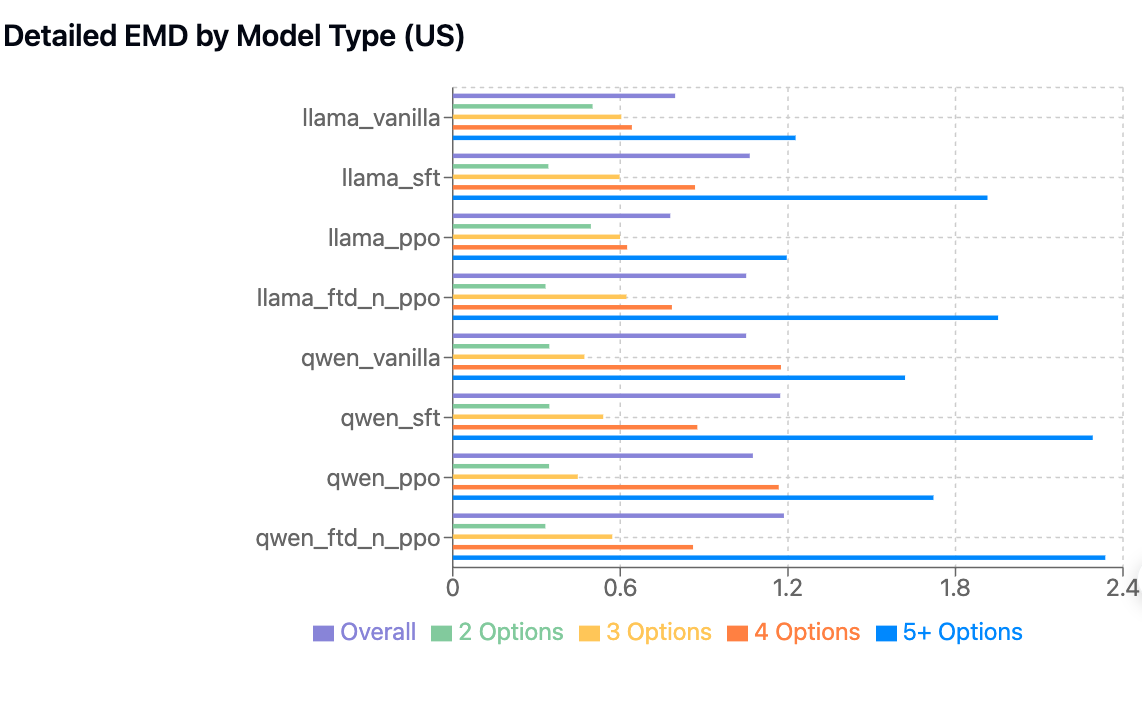

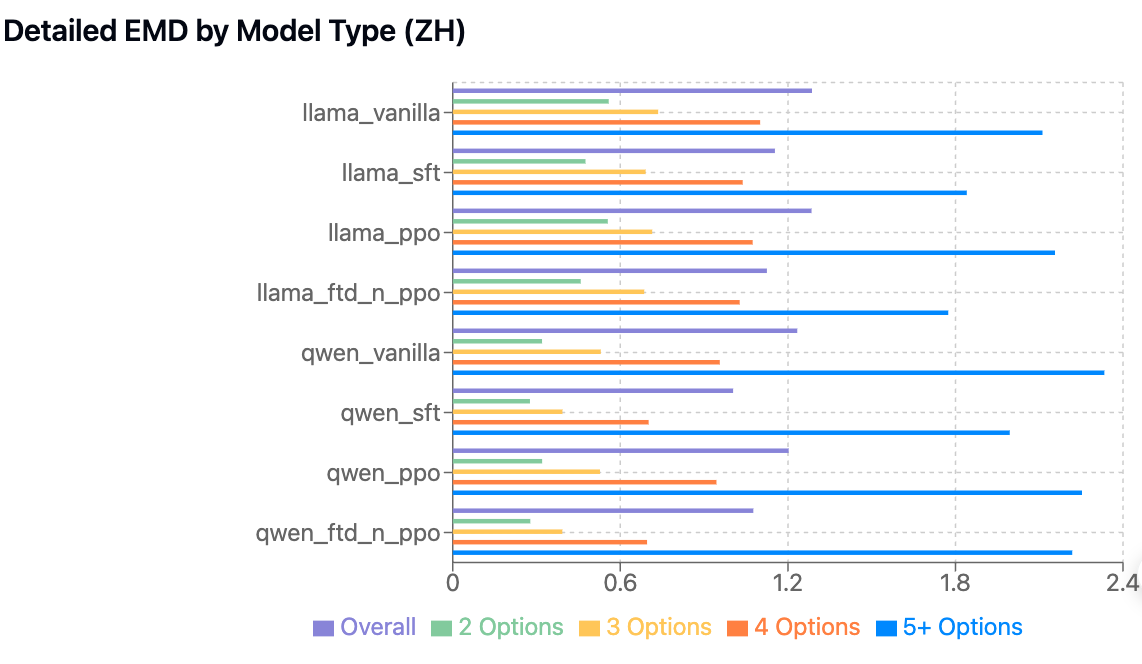

In [ ]:
display(results_table.query("country_name == 'US'")[['model_class', 'model_type', 'emd(overall)']])

display(results_table.query("country_name == 'ZH'")[['model_class', 'model_type', 'emd(overall)']])

,model_class,model_type,emd(overall)
0,llama,llama_vanilla,0.796167
1,llama,llama_sft,1.063369
2,llama,llama_ppo,0.778724
3,llama,llama_ftd_n_ppo,1.050589
4,qwen,qwen_vanilla,1.050403
5,qwen,qwen_sft,1.172459
6,qwen,qwen_ppo,1.074508
7,qwen,qwen_ftd_n_ppo,1.185701


,model_class,model_type,emd(overall)
8,llama,llama_vanilla,1.283647
9,llama,llama_sft,1.153498
10,llama,llama_ppo,1.284595
11,llama,llama_ftd_n_ppo,1.124774
12,qwen,qwen_vanilla,1.233466
13,qwen,qwen_sft,1.003742
14,qwen,qwen_ppo,1.202703
15,qwen,qwen_ftd_n_ppo,1.078104


# Results
1. EMD increases with option count: Across most models, EMD values rise as option count increases (from emd(2) to emd(>=5)). 
    - Since lower EMD indicates better alignment between distributions, models generally perform better on simpler tasks with fewer options.

2. Fine-tuned models outperform base models (how significant the outperforming is?):
    - SFT (supervised fine-tuned) models typically show lower EMD than their vanilla counterparts
    - PPO-based models generally demonstrate better distribution alignment than vanilla models
    - The combination of fine-tuning techniques (ftd_n_ppo) often yields the best results




3. Country-specific differences:
    - US models frequently achieve lower EMD scores than ZH models of the same type
    - This suggests US models may better align with the ground truth distributions


4. Model architecture patterns:
    - Qwen models show stronger performance (lower EMD) for 2-3 options compared to Llama models
    - Llama models sometimes achieve better alignment on more complex distributions (4+ options)


5. Top performers:
    - For 2 options: ZH qwen_sft (0.276271) has the best alignment
    - For 3 options: ZH qwen_ftd_n_ppo (0.391293) performs best
    - Overall: US llama_ftd_n_ppo (1.050589) achieves one of the lowest overall EMD scores

## Surpriging results 
### Overall (emd)
1. models trained on PPO don't impact too much on the EMD (slight reduction), this might be caused by the small training data? (10% of the training data)
2. sft vs ftd_n_ppo: continue ppo on top of fine-tune the model cause the emd increase; **but it made the +>5 options emd improved a lot on English (not Chinese)**, which make senses somehow because our ranking problems are more aligned with more options. **Does this mean there is a high correlation between the task alignment and final score?**
3. Qwen helps reducing the 2 options much more in both English and Mandarin.


## Country Differences (US vs. ZH)

1. Option Count Scaling:
    - ZH models consistently show higher EMD values across all option counts compared to US models
    - The gap between US and ZH models widens as option count increases, suggesting US models handle complex distributions better


2. Performance at 2 Options:
    - ZH qwen models actually outperform US models on 2-option tasks, with ZH qwen_sft having the lowest EMD(2) value (0.276)
    - This suggests ZH models may be better tuned for simple binary distributions

3. Performance at Higher Options (≥5):
    - US models show significantly better performance on complex distributions with 5+ options
    - US llama_ppo has the lowest EMD(≥5) value among all models (1.195)



## Model Type Differences
    - **Fine-tuning Effects**:

        - SFT (supervised fine-tuning) consistently improves performance on simpler distributions (2-3 options) for both countries
        - PPO fine-tuning shows more consistent improvements across all option counts for US models
        - The combined ftd_n_ppo approach shows mixed results - sometimes better, sometimes worse than single fine-tuning methods


    - **Model Architecture Differences**:
        - Llama models scale better with increasing option counts - they don't degrade as quickly as option count increases
        - Qwen models excel at simpler distributions (2-3 options) but show steeper performance degradation at higher option counts
        - This pattern is consistent across both countries


    - **Most Interesting Crossovers**:

        - **US llama_ppo performs exceptionally well on both simple and complex distributions**
        - **ZH qwen_sft excels at simple distributions** but degrades quickly with more options
        - The most balanced model appears to be US llama_ftd_n_ppo, maintaining relatively good performance across different option counts